## Import Library

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

import warnings
warnings.filterwarnings("ignore")

C:\Users\nicor\anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Load Dataset

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## Dataset Information

In [3]:
print("Shape Dataset :", df.shape)
df.info()

Shape Dataset : (6607, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence       

## Statistik Deskriptif

In [4]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## Cek Missing Value

In [5]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

## Menangani Missing Value

In [6]:
for col in df.columns:

    if df[col].dtype == 'object':
        df[col].fillna(
            df[col].mode()[0],
            inplace=True
        )

    else:
        df[col].fillna(
            df[col].median(),
            inplace=True
        )

print("Missing Value Berhasil Dibersihkan")

Missing Value Berhasil Dibersihkan


## Verifikasi Missing Value

In [7]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

## Distribusi Nilai Ujian

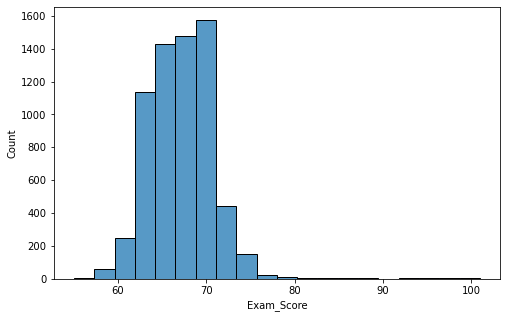

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Exam_Score",
    bins=20
)

plt.show()

## Hours Studied vs Exam Score

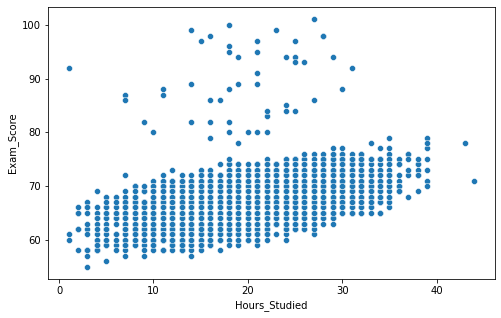

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Hours_Studied",
    y="Exam_Score"
)

plt.show()

## Attendance vs Exam Score

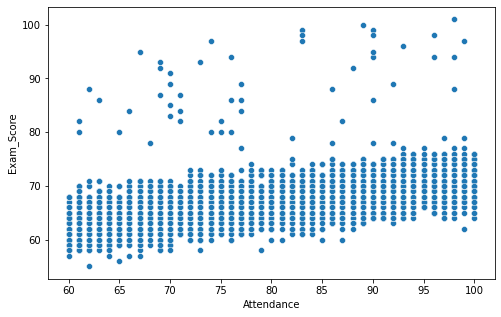

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Attendance",
    y="Exam_Score"
)

plt.show()

## Motivation Level

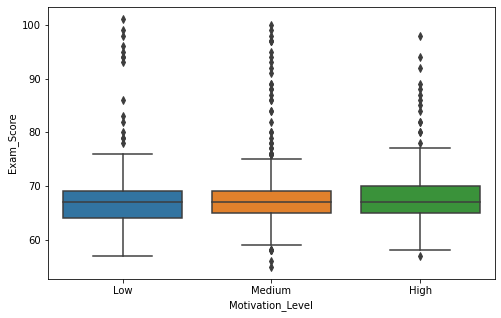

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Motivation_Level",
    y="Exam_Score"
)

plt.show()

## Correlation Heatmap

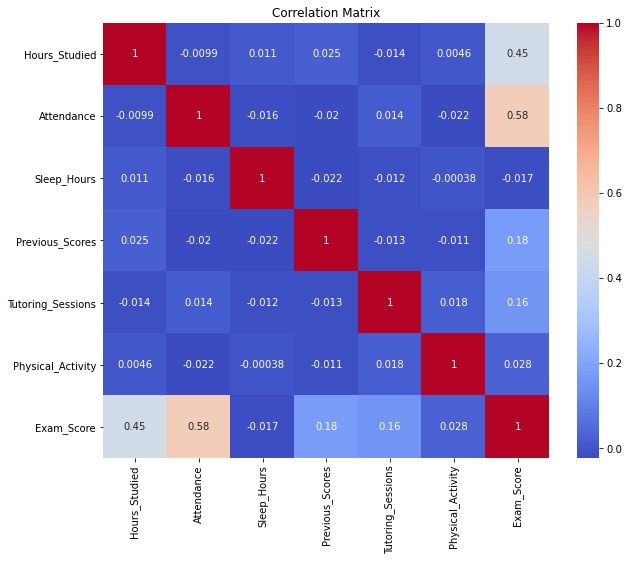

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Membuat Target Klasifikasi

In [13]:
df["Performance"] = np.where(
    df["Exam_Score"] >= 68,
    1,
    0
)

df["Performance"].value_counts()

Performance
0    3599
1    3008
Name: count, dtype: int64

## Encoding Kategorikal

In [14]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Performance
0,23,84,1,0,0,7,73,1,1,0,...,2,1,2,3,0,1,2,1,67,0
1,19,64,1,2,0,8,59,1,1,2,...,2,1,0,4,0,0,1,0,61,0
2,24,98,2,2,1,7,91,2,1,2,...,2,1,1,4,0,2,2,1,74,1
3,29,89,1,2,1,8,98,2,1,1,...,2,1,0,4,0,1,1,1,71,1
4,19,92,2,2,1,6,65,2,1,3,...,0,1,1,4,0,0,2,0,70,1


## Feature dan Target

In [15]:
X = df.drop(
    ["Exam_Score","Performance"],
    axis=1
)

y = df["Performance"]

print(X.shape)
print(y.shape)

(6607, 19)
(6607,)


## Feature Scaling

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Split Dataset

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5285, 19)
(1322, 19)


## Decision Tree Training

In [18]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

## Decision Tree Prediction

In [19]:
dt_pred = dt_model.predict(X_test)

## Evaluasi Decision Tree

In [20]:
print("=== DECISION TREE ===")
print(
    "Accuracy:",
    accuracy_score(y_test, dt_pred)
)
print(
    "Precision:",
    precision_score(y_test, dt_pred)
)
print(
    "Recall:",
    recall_score(y_test, dt_pred)
)
print(
    "F1 Score:",
    f1_score(y_test, dt_pred)
)

=== DECISION TREE ===
Accuracy: 0.8154311649016641
Precision: 0.7961476725521669
Recall: 0.8091353996737357
F1 Score: 0.8025889967637541


## Random Forest Training

In [21]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

## Random Forest Prediction

In [22]:
rf_pred = rf_model.predict(X_test)

## Evaluasi Random Forest

In [23]:
print("=== RANDOM FOREST ===")
print(
    "Accuracy:",
    accuracy_score(y_test, rf_pred)
)
print(
    "Precision:",
    precision_score(y_test, rf_pred)
)
print(
    "Recall:",
    recall_score(y_test, rf_pred)
)
print(
    "F1 Score:",
    f1_score(y_test, rf_pred)
)

=== RANDOM FOREST ===
Accuracy: 0.9114977307110439
Precision: 0.9175084175084175
Recall: 0.8890701468189234
F1 Score: 0.9030654515327258


## Classification Report

In [24]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       709
           1       0.92      0.89      0.90       613

    accuracy                           0.91      1322
   macro avg       0.91      0.91      0.91      1322
weighted avg       0.91      0.91      0.91      1322



## Confusion Matrix

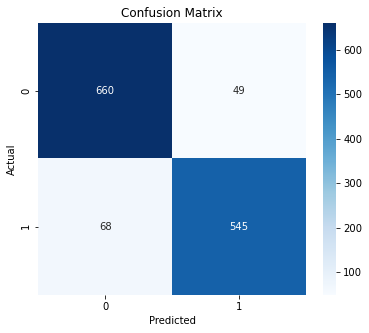

In [25]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Feature Importance

In [26]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Attendance,0.375208
0,Hours_Studied,0.195714
6,Previous_Scores,0.082183
9,Tutoring_Sessions,0.041323
3,Access_to_Resources,0.034479
5,Sleep_Hours,0.033718
14,Physical_Activity,0.028055
2,Parental_Involvement,0.027945
13,Peer_Influence,0.023694
16,Parental_Education_Level,0.022339


## Visualisasi Feature Importance

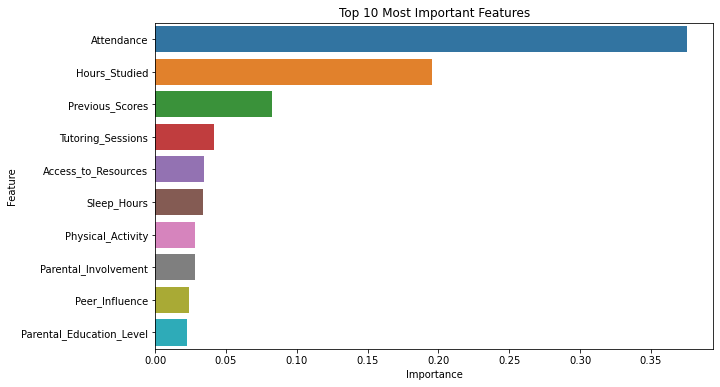

In [27]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Most Important Features"
)

plt.show()

## Simpan Model

In [28]:
joblib.dump(
    rf_model,
    "model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Model berhasil disimpan")

Model berhasil disimpan


## Test Load Model

In [29]:
loaded_model = joblib.load(
    "model.pkl"
)

loaded_scaler = joblib.load(
    "scaler.pkl"
)

print("Model berhasil dimuat")

Model berhasil dimuat
